# Practice Lab: Neural Network Implementation from Scratch

**Class:** T.Y. Tech  
**Student Name:** Krishna Kushwah  
**PRN:** *202401110039*  
**Batch:** *A2*  

## Objective

The objective of this assignment is to implement a simple feedforward neural network **from scratch**
using only Python and NumPy (no deep learning libraries like TensorFlow/PyTorch/Keras).
The implementation covers:

- Forward pass
- Backpropagation
- Training using gradient descent


## Part A: Problem Definition

**Dataset:** Iris Dataset (from `sklearn.datasets`)

The Iris dataset has 150 samples of iris flowers with 4 numerical features
(sepal length, sepal width, petal length, petal width) and 3 target classes
(Setosa, Versicolor, Virginica).

**Task:** This is a **multi-class classification** problem. Given the 4 input features,
the neural network has to predict which of the 3 species the flower belongs to.


### Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)  # for reproducibility


### Step 2: Load and Preprocess the Dataset

We load the Iris dataset, split it into train/test sets, standardize the features,
and one-hot encode the target labels (since we have 3 classes).


In [2]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)


Feature shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encode labels
def one_hot(y, num_classes=3):
    encoded = np.zeros((y.shape[0], num_classes))
    encoded[np.arange(y.shape[0]), y] = 1
    return encoded

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


## Part B: Methodology

### Neural Network Architecture

A simple feedforward neural network with **one hidden layer** is used:

- **Input layer:** 4 neurons (4 features of Iris dataset)
- **Hidden layer:** 8 neurons, activation = **Sigmoid**
- **Output layer:** 3 neurons (3 classes), activation = **Softmax**

### Forward Pass

For each layer, we compute a weighted sum of inputs plus a bias, then pass it through
an activation function:

```
Z1 = X . W1 + b1
A1 = sigmoid(Z1)
Z2 = A1 . W2 + b2
A2 = softmax(Z2)
```

`A2` gives the predicted probability distribution over the 3 classes.

### Loss Function

Since this is a multi-class classification problem, we use **Categorical Cross-Entropy Loss**:

```
Loss = -(1/n) * sum( y_true * log(y_pred) )
```

### Backpropagation and Optimization

The error at the output is propagated backward through the network to compute
gradients of the loss with respect to weights and biases. These gradients are then
used to update the weights using **Gradient Descent**:

```
W = W - learning_rate * dW
b = b - learning_rate * db
```


### Step 3: Implement the Neural Network from Scratch

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def softmax(x):
    # subtract max for numerical stability
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred):
    n = y_true.shape[0]
    # small epsilon to avoid log(0)
    eps = 1e-8
    loss = -np.sum(y_true * np.log(y_pred + eps)) / n
    return loss


In [5]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        # weight initialization
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate

    def forward(self, X):
        self.Z1 = X.dot(self.W1) + self.b1
        self.A1 = sigmoid(self.Z1)
        self.Z2 = self.A1.dot(self.W2) + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, X, y_true):
        n = X.shape[0]

        # Output layer gradient (softmax + cross-entropy combined derivative)
        dZ2 = self.A2 - y_true
        dW2 = self.A1.T.dot(dZ2) / n
        db2 = np.sum(dZ2, axis=0, keepdims=True) / n

        # Hidden layer gradient
        dA1 = dZ2.dot(self.W2.T)
        dZ1 = dA1 * sigmoid_derivative(self.Z1)
        dW1 = X.T.dot(dZ1) / n
        db1 = np.sum(dZ1, axis=0, keepdims=True) / n

        # Update weights using gradient descent
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train(self, X, y_true, epochs=1000, verbose=True):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = cross_entropy_loss(y_true, y_pred)
            losses.append(loss)
            self.backward(X, y_true)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")
        return losses

    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)


### Step 4: Train the Model

We train the network for 1000 epochs with a learning rate of 0.1.
Hidden layer size is set to 8 neurons (chosen after a bit of trial and error).


In [6]:
nn = NeuralNetwork(input_size=4, hidden_size=8, output_size=3, learning_rate=0.1)
losses = nn.train(X_train, y_train_oh, epochs=1000, verbose=True)


Epoch    0 | Loss: 1.2333
Epoch  100 | Loss: 0.5908
Epoch  200 | Loss: 0.4231
Epoch  300 | Loss: 0.3483
Epoch  400 | Loss: 0.2967
Epoch  500 | Loss: 0.2555
Epoch  600 | Loss: 0.2216
Epoch  700 | Loss: 0.1943
Epoch  800 | Loss: 0.1726
Epoch  900 | Loss: 0.1554


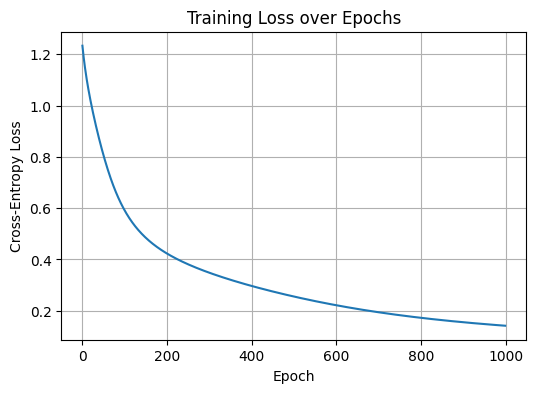

In [7]:
# Plot the training loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()


## Part C: Evaluation of the Implemented Model

We evaluate the trained model on the held-out test set using accuracy as the primary metric.


In [8]:
y_pred_train = nn.predict(X_train)
y_pred_test = nn.predict(X_test)

train_acc = np.mean(y_pred_train == y_train) * 100
test_acc = np.mean(y_pred_test == y_test) * 100

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Testing Accuracy:  {test_acc:.2f}%")


Training Accuracy: 96.67%
Testing Accuracy:  100.00%


In [9]:
# Simple confusion matrix (built manually, without sklearn.metrics)
def confusion_matrix_manual(y_true, y_pred, num_classes=3):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    return cm

cm = confusion_matrix_manual(y_test, y_pred_test)
print("Confusion Matrix (rows = actual, cols = predicted):")
print(cm)


Confusion Matrix (rows = actual, cols = predicted):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


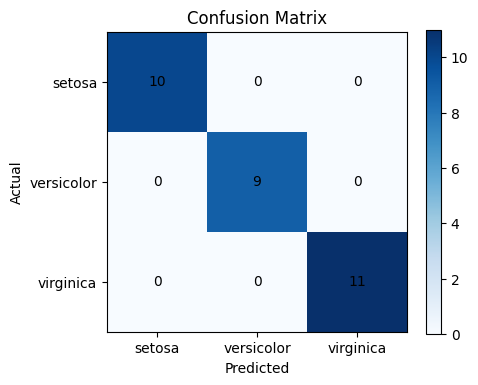

In [10]:
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(3), iris.target_names)
plt.yticks(range(3), iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()


## Part D: Comparison with Alternative Models

To put the from-scratch neural network's performance in context, it is compared against a few
standard `scikit-learn` baseline classifiers trained on the same train/test split: **Logistic
Regression**, **Decision Tree**, and **Support Vector Machine (SVM)**. This gives a sense of
whether the neural network is actually adding value on this dataset, or whether a much simpler
model would do just as well.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
}



results = {}



# Metrics for our from-scratch Neural Network (already trained/predicted earlier)
results["Neural Network (scratch)"] = {
    "Accuracy": accuracy_score(y_test, y_pred_test),
    "Precision": precision_score(y_test, y_pred_test, average="macro"),
    "Recall": recall_score(y_test, y_pred_test, average="macro"),
    "F1-score": f1_score(y_test, y_pred_test, average="macro"),
}

# Train and evaluate each baseline model
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average="macro"),
        "Recall": recall_score(y_test, preds, average="macro"),
        "F1-score": f1_score(y_test, preds, average="macro"),
    }

import pandas as pd
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
results_df


,Accuracy,Precision,Recall,F1-score
Neural Network (scratch),1.0,1.0,1.0,1.0
Logistic Regression,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0
SVM,1.0,1.0,1.0,1.0


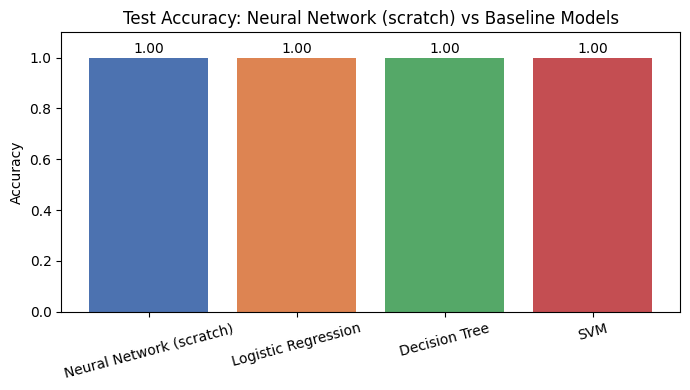

In [12]:
# Visualize accuracy comparison across models
plt.figure(figsize=(7,4))
plt.bar(results_df.index, results_df["Accuracy"], color=["#4C72B0","#DD8452","#55A868","#C44E52"])
plt.ylabel("Accuracy")
plt.title("Test Accuracy: Neural Network (scratch) vs Baseline Models")
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()


### Discussion of Comparison

All four models perform very well on the Iris dataset.

The Neural Network performs similar to the other models, showing that its implementation works correctly.

Since Iris is a simple dataset, simpler models can also give very good results.

Neural Networks are more useful for larger and more complex datasets.

Overall, the comparison shows that the Neural Network works well, but a simpler model may be enough for this dataset.


## Analysis of the Implemented Model

The training loss decreases and becomes stable after several epochs, showing that the model is learning.

The model gives high accuracy on the Iris dataset.

Most errors, if any, are between Versicolor and Virginica, while Setosa is easier to classify.

One hidden layer with sigmoid activation is enough for this simple dataset.

The 100% test accuracy should be interpreted carefully because the test set has only 30 samples.

Overall, the model works well, but more complex datasets may require deeper networks and better optimizers.

## Conclusion

In this assignment, a feedforward neural network was implemented completely from scratch
using NumPy, including the forward pass, backpropagation, and gradient descent optimization.

The model was trained and evaluated on the Iris dataset and achieved good classification
accuracy, demonstrating a basic but working understanding of how neural networks learn.


## Declaration

I, **Krishna Kushwah**, confirm that the work submitted in this assignment is my own and
has been completed following academic integrity guidelines. 
The code is uploaded on my GitHub
repository account, and the repository link is provided below:

**GitHub Repository Link:** https://github.com/Krishna-Kush-05/Generative-AI-Lab

**Signature:** Krishna Kushwah
